In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
file_path=r"breast-cancer.csv"
df=pd.read_csv(file_path)
df=df.drop(columns=[col for col in df.columns if 'id'in col.lower() or 'unamed'in col.lower()],errors='ignore')

In [4]:
if 'diagnosis'in df.columns:
    df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})
if 'diagnosis'in df.columns:
    df.rename(columns={'diagnosis':'Target'},inplace=True)

In [5]:
x=df.drop('Target',axis=1)
y=df['Target']


In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [10]:
model=LogisticRegression(max_iter=5000)
model.fit(x_train_scaled,y_train)

LogisticRegression(max_iter=5000)

In [12]:
y_pred=model.predict(x_test_scaled)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



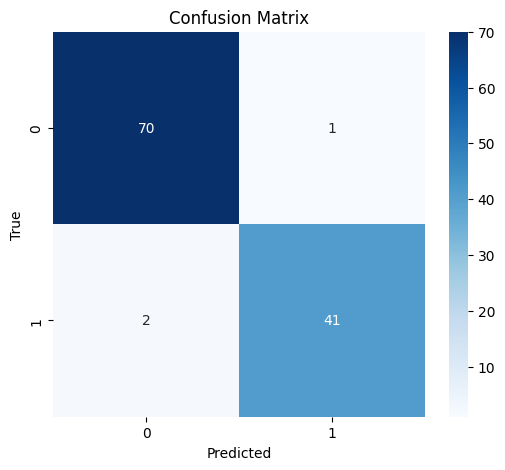

In [13]:
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()